<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


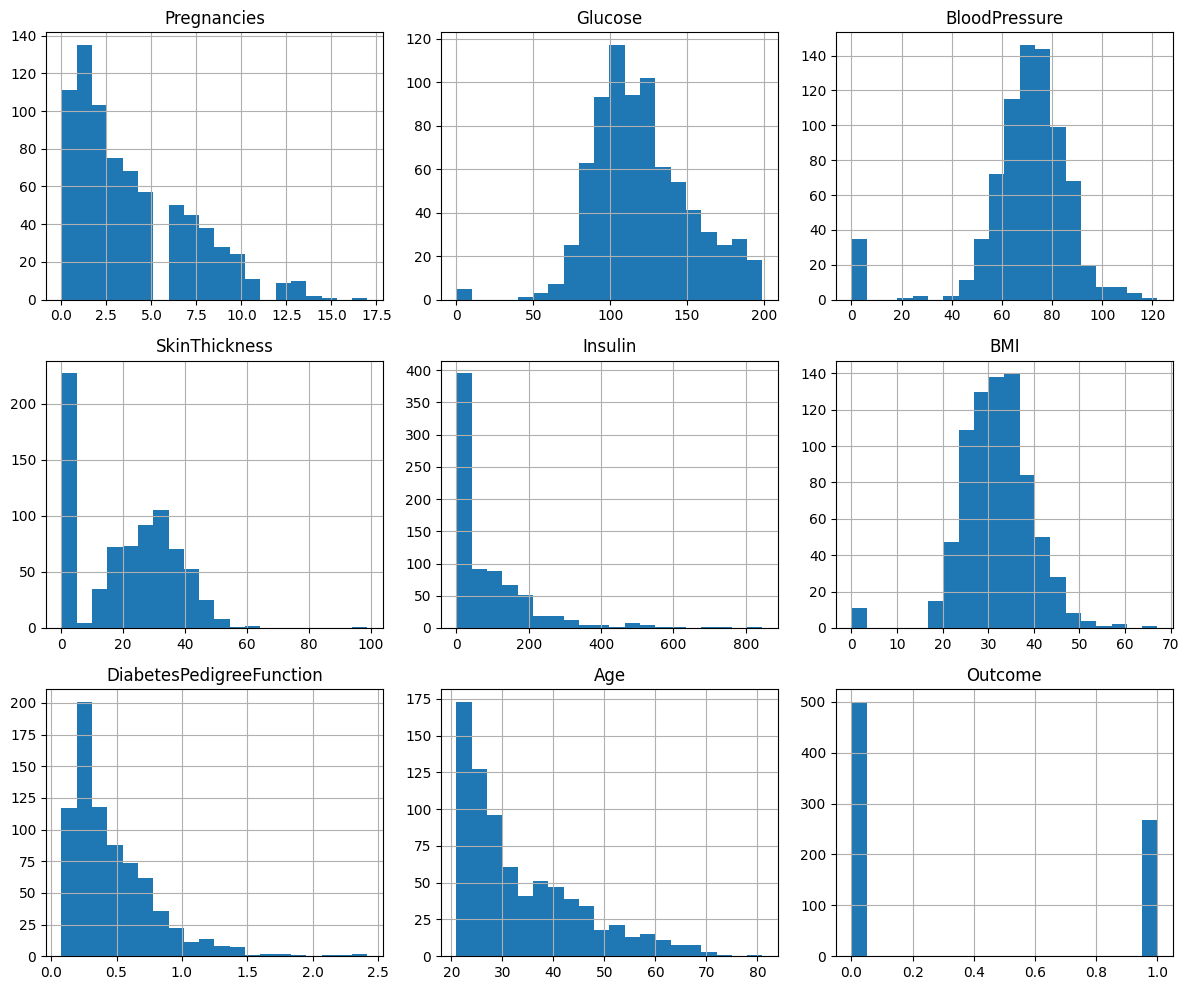

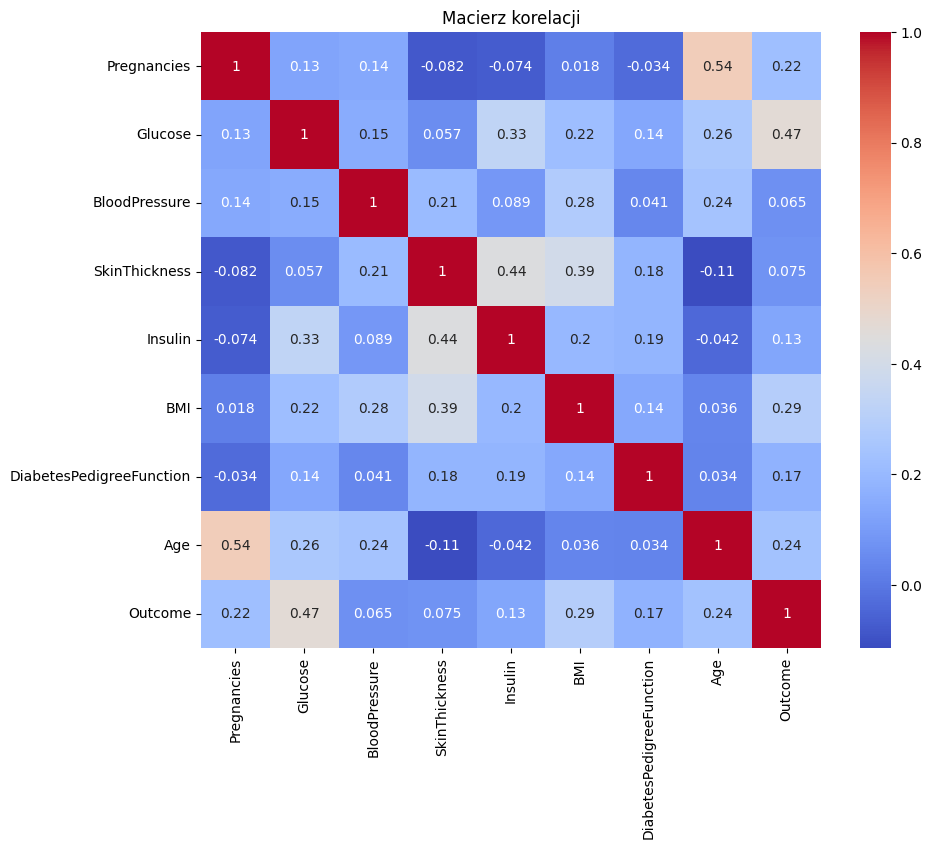

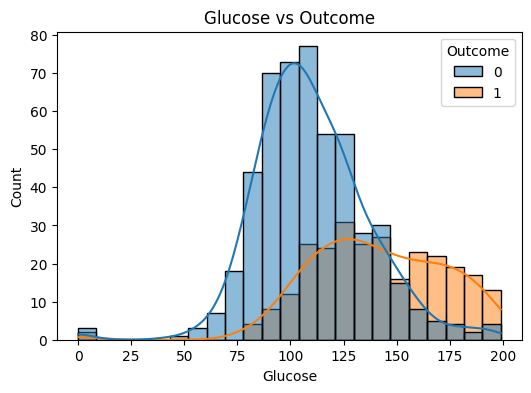

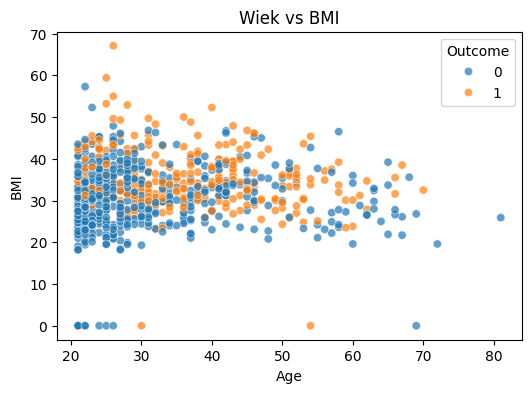

Accuracy: 0.7402597402597403
Precision: 0.6346153846153846
Recall: 0.6111111111111112
F1: 0.6226415094339622
AUC: 0.8177777777777778


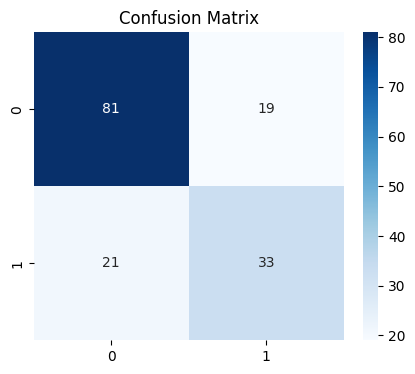

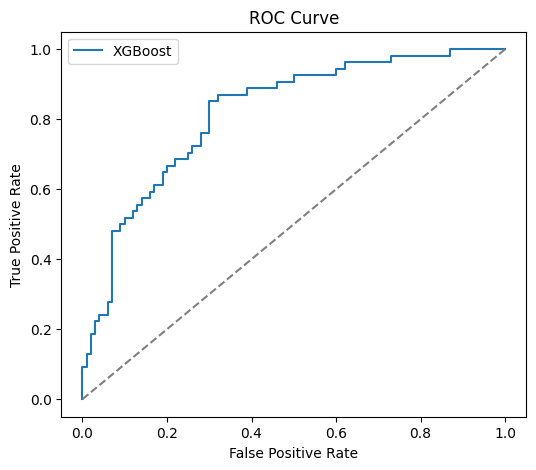

['xgboost_diabetes_model.pkl']

In [12]:
# 1.Import bibliotek i wczytanie danych
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

from xgboost import XGBClassifier

# 2.Dane z kaggla o diabetes
# Tworzymy folder na wykresy
FOLDER = "figures"
if not os.path.exists(FOLDER):
    os.makedirs(FOLDER)

# Wczytanie danych
df = pd.read_csv("diabetes.csv")
df.head()

# Podstawowe informacje o danych
df.info()
df.describe()
df.isnull().sum()

# 3. Wizualizacje
# Histogramy wszystkich zmiennych
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.savefig(f"{FOLDER}/histogramy_wszystkich_zmiennych.png")
plt.show()

# Korelacje
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Macierz korelacji")
plt.savefig(f"{FOLDER}/korelacje.png")
plt.show()

# Histogram glukozy vs diabetes
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="Glucose", hue="Outcome", kde=True)
plt.title("Glucose vs Outcome")
plt.savefig(f"{FOLDER}/glucose_vs_outcome.png")
plt.show()

# Wiek vs BMI
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Age", y="BMI", hue="Outcome", alpha=0.7)
plt.title("Wiek vs BMI")
plt.savefig(f"{FOLDER}/age_vs_BMI.png")
plt.show()

# 4. Przygotowanie danych
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Model XGBoost
model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss'
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 6. Metryki
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig(f"{FOLDER}/confusion_matrix.png")
plt.show()

# 8. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1], [0,1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig(f"{FOLDER}/roc_curve.png")
plt.show()

# 9. Zapisanie finalnego modelu (opcjonalnie
import joblib
joblib.dump(model, "xgboost_diabetes_model.pkl")
















